# Experiment 08 (Advanced): Advanced K-Means Clustering & Cluster Validation Diagnostics
## Title: Comprehensive Analysis: High-Dimensional Clustering on Handwritten Digits, K-Means++ vs Random Initialization, WCSS/Silhouette/Calinski-Harabasz/Davies-Bouldin Metrics, PCA Dimensionality Reduction Before Clustering, Per-Sample Silhouette Diagnostics, and Voronoi Tessellation

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Advanced Libraries & Setup Environment

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial import Voronoi, voronoi_plot_2d

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(33)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All necessary libraries imported successfully.")

All necessary libraries imported successfully.


### Step 2: Load Dataset & Feature Standardization - Handwritten Digits
This experiment deliberately uses a **high-dimensional, real-world dataset** — the **Optical Recognition of Handwritten Digits** dataset (1,797 samples, 64 pixel-intensity features, 10 natural classes) — rather than a small 2-4 feature toy dataset. This makes several advanced diagnostics (PCA-before-clustering, per-sample silhouette analysis, initialization stability) meaningfully non-trivial, since 64-dimensional clustering behaves very differently from clustering in 2-4 dimensions.

Digits Dataset Shape   : (1797, 64)
Number of true classes : 10


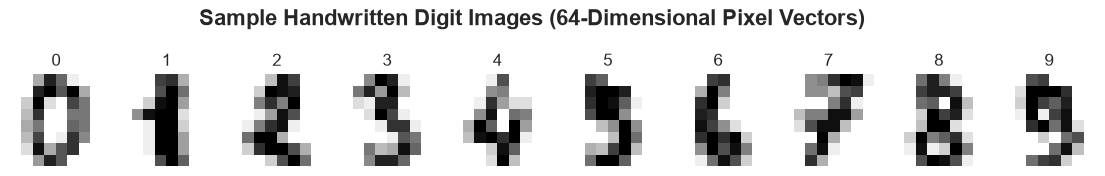

In [2]:
digits   = load_digits()
x        = digits.data
y_true   = digits.target

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)

print(f"Digits Dataset Shape   : {x_scaled.shape}")
print(f"Number of true classes : {len(np.unique(y_true))}")

fig, axes = plt.subplots(1, 10, figsize=(14, 2))

for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(str(y_true[i]))
    ax.axis("off")
fig.suptitle("Sample Handwritten Digit Images (64-Dimensional Pixel Vectors) ", y=1.05, fontsize=16, fontweight='bold')
plt.show()

### Step 3: WCSS Elbow Method & Internal Validation Metrics
Four complementary internal validation metrics are computed across a range of K values:
- **WCSS (Inertia)**: total within-cluster variance - lower is tighter, but always decreases with K
- **Silhouette Score**: how well-separated clusters are (range -1 to 1, higher is better)
- **Calinski-Harabasz Index**: ratio of between-cluster to within-cluster dispersion (higher is better)
- **Davies-Bouldin Index**: average similarity between each cluster and its most similar neighbor (lower is better)

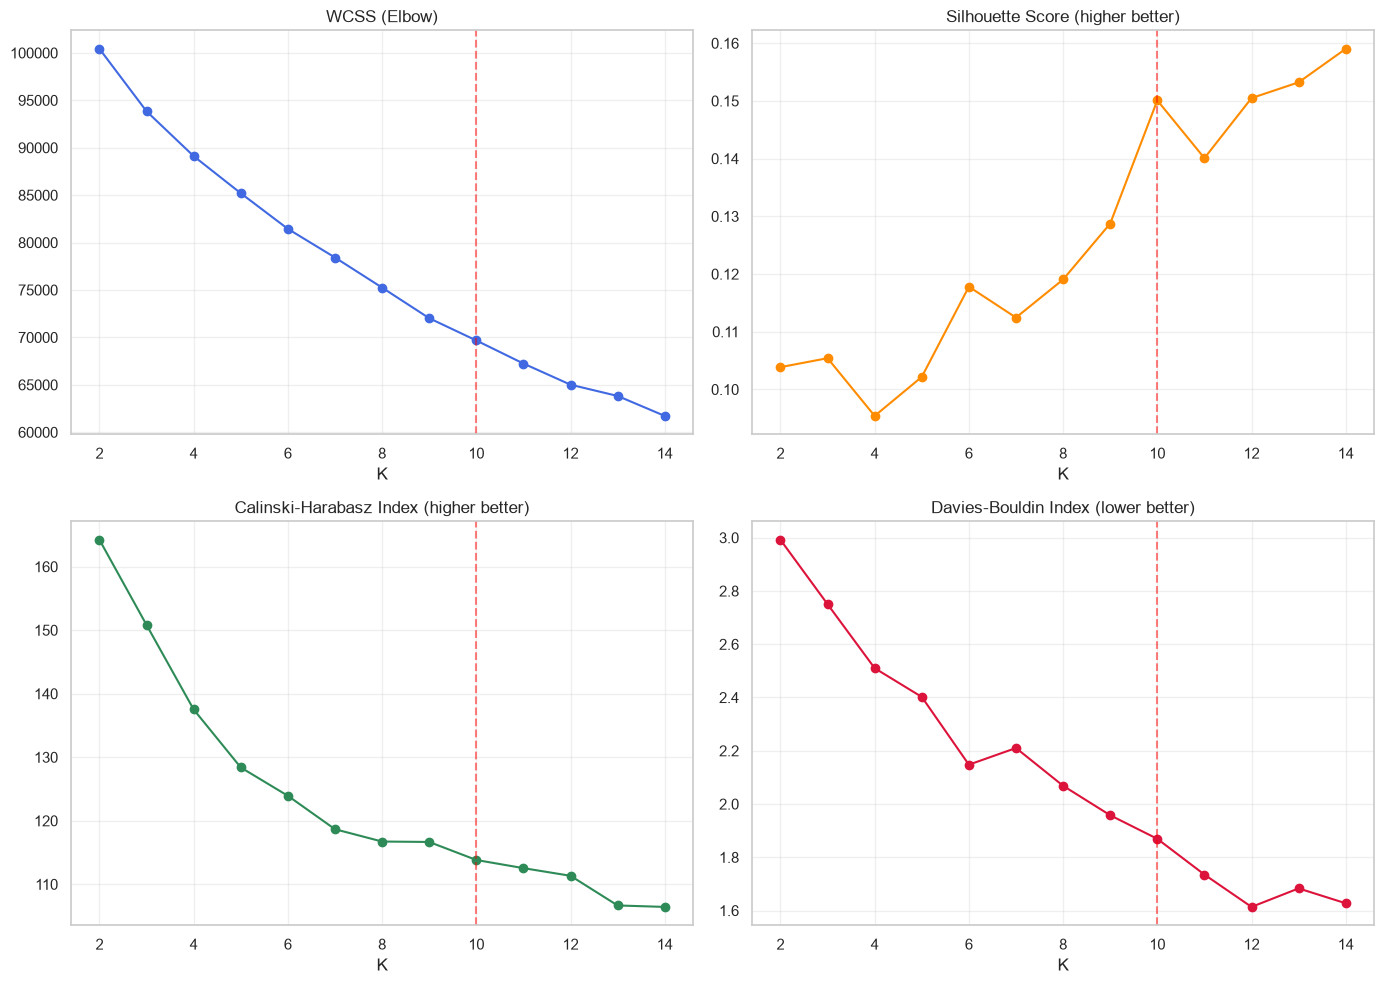

,K,WCSS,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,2,100428.893683,0.103861,164.222170,2.992002
1,3,93839.407013,0.105415,150.816180,2.750274
2,4,89113.314732,0.095410,137.514459,2.509995
3,5,85200.547682,0.102171,128.386154,2.402010
4,6,81441.076990,0.117804,123.925370,2.147632
5,7,78423.265335,0.112450,118.665434,2.210248
6,8,75248.652984,0.119050,116.727240,2.068416
7,9,72022.979565,0.128744,116.660872,1.957715
8,10,69675.085009,0.150088,113.823889,1.869172
9,11,67244.720839,0.140081,112.539527,1.734935


In [3]:
k_range = list(range(2, 15))
wcss, sil_scores, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km     = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=33)
    labels = km.fit_predict(x_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(x_scaled, labels))
    ch_scores.append(calinski_harabasz_score(x_scaled, labels))
    db_scores.append(davies_bouldin_score(x_scaled, labels))

metrics_df = pd.DataFrame({
    "K"                       : k_range, 
    "WCSS"                    : wcss,
    "Silhouette Score"        : sil_scores,
    "Calinski-Harabasz Index" : ch_scores,
    "Davies-Bouldin Index"    : db_scores
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(k_range, wcss,       marker="o", color="royalblue");  axes[0,0].set_title("WCSS (Elbow)");                            axes[0,0].axvline(10, ls="--", c="red", alpha=0.5)
axes[0,1].plot(k_range, sil_scores, marker="o", color="darkorange"); axes[0,1].set_title("Silhouette Score (higher better)");        axes[0,1].axvline(10, ls="--", c="red", alpha=0.5)
axes[1,0].plot(k_range, ch_scores,  marker="o", color="seagreen");   axes[1,0].set_title("Calinski-Harabasz Index (higher better)"); axes[1,0].axvline(10, ls="--", c="red", alpha=0.5)
axes[1,1].plot(k_range, db_scores,  marker="o", color="crimson");    axes[1,1].set_title("Davies-Bouldin Index (lower better)");     axes[1,1].axvline(10, ls="--", c="red", alpha=0.5)

for ax in axes.flat:
    ax.set_xlabel("K"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

metrics_df

### Step 4: Initialization Stability - K-Means++ vs Random Initialization
K-Means is sensitive to centroid initialization and can converge to poor local minima. This step empirically compares **K-Means++** (smart, distance-weighted initialization) against **purely random initialization**, running each strategy across 5 different random seeds (with `n_init=1` to isolate the effect of initialization alone) to measure the variance in final inertia.

Inertia Comparison between 'random' and 'k-means++' Initialization Methods:

             random     k-means++
count      5.000000      5.000000
mean   70952.481672  70670.521807
std      933.339734   1067.393836
min    69480.754339  69416.840005
25%    70680.175400  69749.082462
50%    71303.369249  70785.030367
75%    71374.454826  71687.125027
max    71923.654548  71714.531176

Mean Inertia                  :
 random       70952.481672
k-means++    70670.521807
dtype: float64

Standard Deviation of Inertia :
 random        933.339734
k-means++    1067.393836
dtype: float64


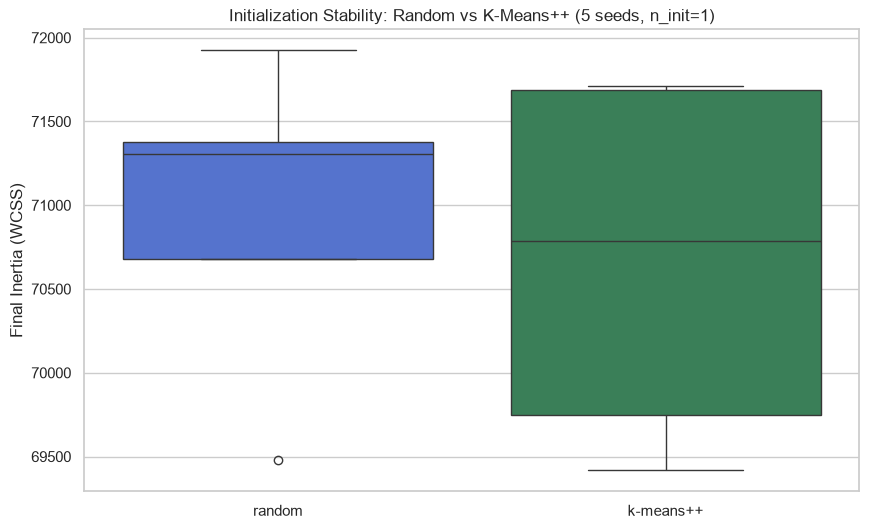

In [4]:
init_comparision = {"random": [], "k-means++": []}

for init_method in init_comparision:
    for seed in range(5):
        km = KMeans(n_clusters=10, init=init_method, n_init=1, random_state=seed)
        km.fit(x_scaled)
        init_comparision[init_method].append(km.inertia_)

init_df = pd.DataFrame(init_comparision)
print("Inertia Comparison between 'random' and 'k-means++' Initialization Methods:\n")
print(init_df.describe())
print("\nMean Inertia                  :\n", init_df.mean())
print("\nStandard Deviation of Inertia :\n", init_df.std())

plt.figure(figsize=(10, 6))
sns.boxplot(data=init_df, palette=["royalblue", "seagreen"])
plt.ylabel("Final Inertia (WCSS)")
plt.title("Initialization Stability: Random vs K-Means++ (5 seeds, n_init=1)")
plt.show()

### Step 5: Dimensionality Reduction Before Clustering (PCA Pre-Processing)
A common advanced technique is to apply PCA **before** clustering, retaining only enough principal components to preserve a target amount of variance. This can denoise high-dimensional data and speed up clustering, though it may also discard information relevant to cluster structure. Both approaches are compared here using the **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** against the true digit labels.

In [5]:
pca_pre   = PCA(n_components=2, random_state=33)
x_pca_pre = pca_pre.fit_transform(x_scaled)

print(f"Components retained to preserve 90% variance: {x_pca_pre.shape[1]} out of {x_scaled.shape[1]} original features.")

km_raw = KMeans(n_clusters=10, init="k-means++", n_init=10, random_state=33).fit(x_scaled)
km_pca = KMeans(n_clusters=10, init="k-means++", n_init=10, random_state=33).fit(x_pca_pre)

labels_raw = km_raw.labels_
labels_pca = km_pca.labels_

pca_comparison = pd.DataFrame({
    "Approach"                : ["Raw Standardized (64-D) Features", "PCA Reduced (2-D) Features"],
    "Dimensionality"          : [x_scaled.shape[1], x_pca_pre.shape[1]],
    "Silhouette Score"        : [silhouette_score(x_scaled, labels_raw), silhouette_score(x_pca_pre, labels_pca)],
    "Calinski-Harabasz Index" : [calinski_harabasz_score(x_scaled, labels_raw), calinski_harabasz_score(x_pca_pre, labels_pca)],
    "Davies-Bouldin Index"    : [davies_bouldin_score(x_scaled, labels_raw), davies_bouldin_score(x_pca_pre, labels_pca)],
    "ARI VS True Labels"      : [adjusted_rand_score(y_true, labels_raw), adjusted_rand_score(y_true, labels_pca)],
    "NMI VS True Labels"      : [normalized_mutual_info_score(y_true, labels_raw), normalized_mutual_info_score(y_true, labels_pca)]
})

pca_comparison

Components retained to preserve 90% variance: 2 out of 64 original features.


,Approach,Dimensionality,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index,ARI VS True Labels,NMI VS True Labels
0,Raw Standardized (64-D) Features,64,0.150088,113.823889,1.869172,0.566691,0.696638
1,PCA Reduced (2-D) Features,2,0.375820,1470.851656,0.786441,0.324030,0.464754


### Step 6: PCA 2D Cluster Centroids & Scatter Visualization

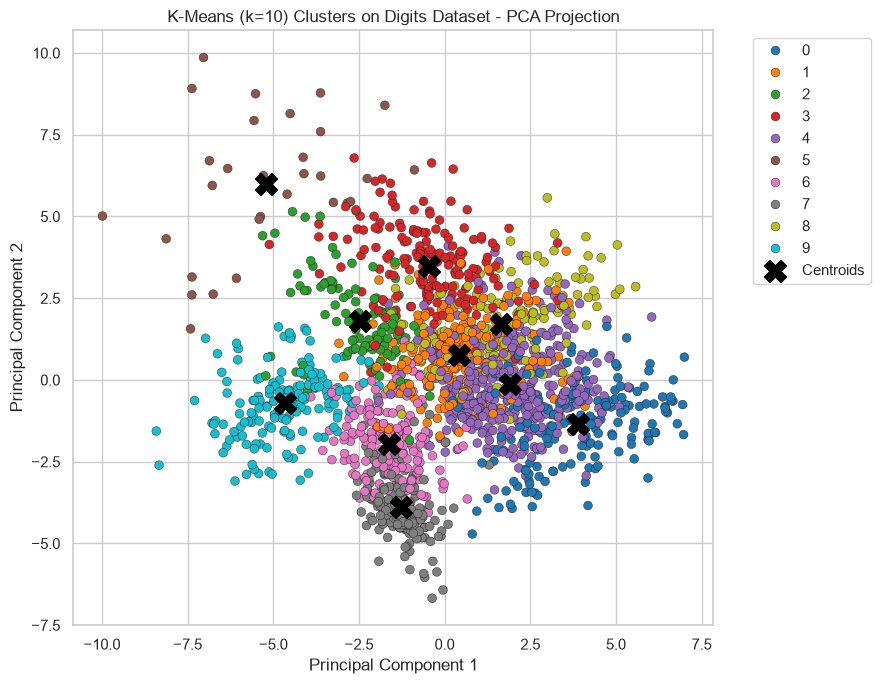

In [6]:
pca2   = PCA(n_components=2, random_state=33)
x_pca2 = pca2.fit_transform(x_scaled)


km_final = KMeans(n_clusters=10, init="k-means++", n_init=10, random_state=33)
cluster_labels = km_final.fit_predict(x_scaled)
centroids_pca2 = pca2.transform(km_final.cluster_centers_)

plt.figure(figsize=(9, 7))
sns.scatterplot(x=x_pca2[:, 0], y=x_pca2[:, 1], hue=cluster_labels, palette="tab10", s=40, edgecolor="k", linewidth=0.3, legend="full")
plt.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1], c="black", marker="X", s=250, label="Centroids")
plt.title("K-Means (k=10) Clusters on Digits Dataset - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Step 7: Per-Sample Silhouette Diagnostics
Beyond the single aggregate silhouette score, plotting the **silhouette coefficient of every individual sample**, grouped by cluster, reveals which specific clusters are well-separated (thick, uniformly high bars) versus which are ambiguous or overlapping (thin bars, or bars dipping below zero).

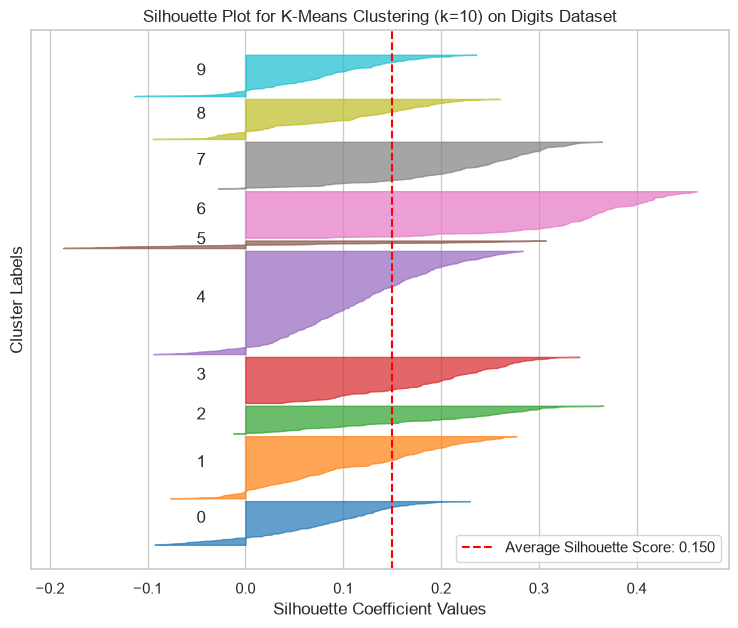

In [7]:
sample_silhouette_values = silhouette_samples(x_scaled, cluster_labels)
avg_silhouette_score     = silhouette_score(x_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(9, 7))
y_lower = 10

for i in range(10):
    cluster_sil_vals = sample_silhouette_values[cluster_labels == i]
    cluster_sil_vals.sort()
    size_cluster_i   = cluster_sil_vals.shape[0]
    y_upper          = y_lower + size_cluster_i
    color            = cm.tab10(float(i) / 10)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower          = y_upper + 10

ax.axvline(x=avg_silhouette_score, color="red", linestyle="--", label=f"Average Silhouette Score: {avg_silhouette_score:.3f}")
ax.set_yticks([])
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster Labels')
ax.set_title("Silhouette Plot for K-Means Clustering (k=10) on Digits Dataset")
ax.legend(loc='lower right')
plt.show()

### Step 8: Cluster Centroids Reconstructed as Digit Images

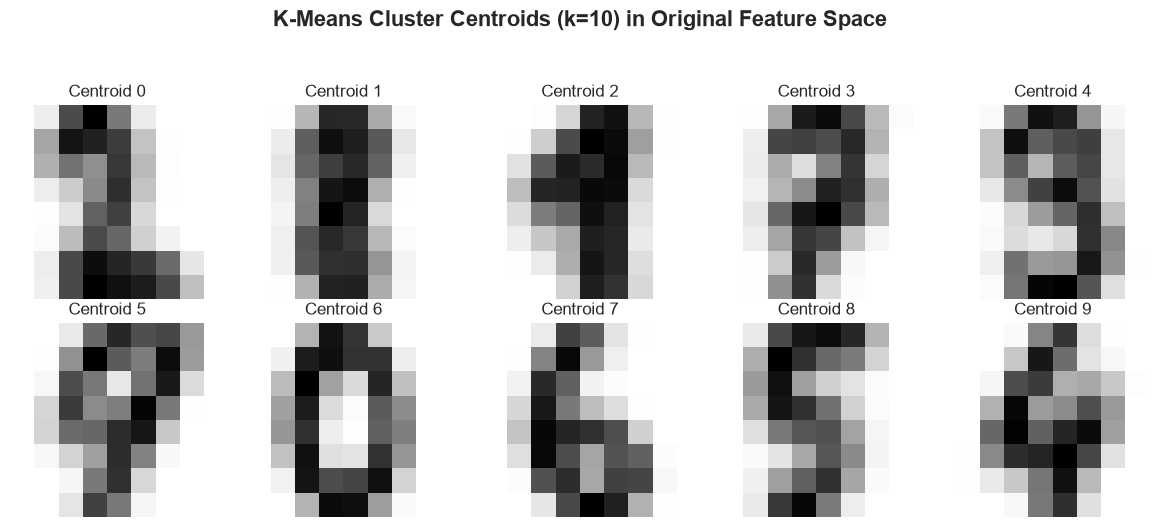

In [8]:
centroids_original_space = scaler.inverse_transform(km_final.cluster_centers_)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(centroids_original_space[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"Centroid {i}")
    ax.axis("off")

fig.suptitle("K-Means Cluster Centroids (k=10) in Original Feature Space", y=1.05, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 9: Voronoi Tessellation of the Cluster Centroids
Voronoi tessellation partitions the 2D PCA-projected plane into regions such that every point within a region is closer to that region's centroid than to any other — this is exactly the decision boundary K-Means uses internally to assign points to clusters.

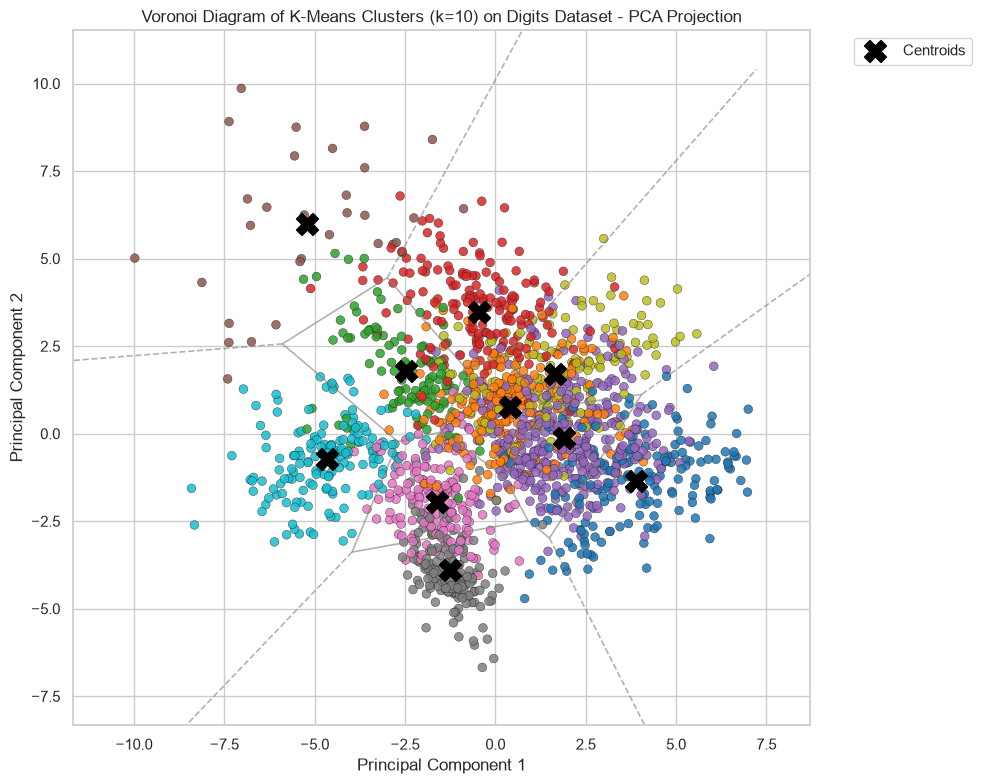

In [9]:
vor      = Voronoi(centroids_pca2)

fig, ax  = plt.subplots(figsize=(10, 8))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="gray", line_width=1.2, line_alpha=0.6, point_size=0)

scatter  = ax.scatter(x_pca2[:, 0], x_pca2[:, 1], c=cluster_labels, cmap="tab10", s=40, edgecolor="k", linewidth=0.3, alpha=0.85)
ax.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1], c="black", marker="X", s=250, label="Centroids")

x_margin = (x_pca2[:, 0].max() - x_pca2[:, 0].min()) * 0.1
y_margin = (x_pca2[:, 1].max() - x_pca2[:, 1].min()) * 0.1
ax.set_xlim(x_pca2[:, 0].min() - x_margin, x_pca2[:, 0].max() + x_margin)
ax.set_ylim(x_pca2[:, 1].min() - y_margin, x_pca2[:, 1].max() + y_margin)

ax.set_title("Voronoi Diagram of K-Means Clusters (k=10) on Digits Dataset - PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Step 10: Cluster-to-Digit Alignment & Final Validation Summary

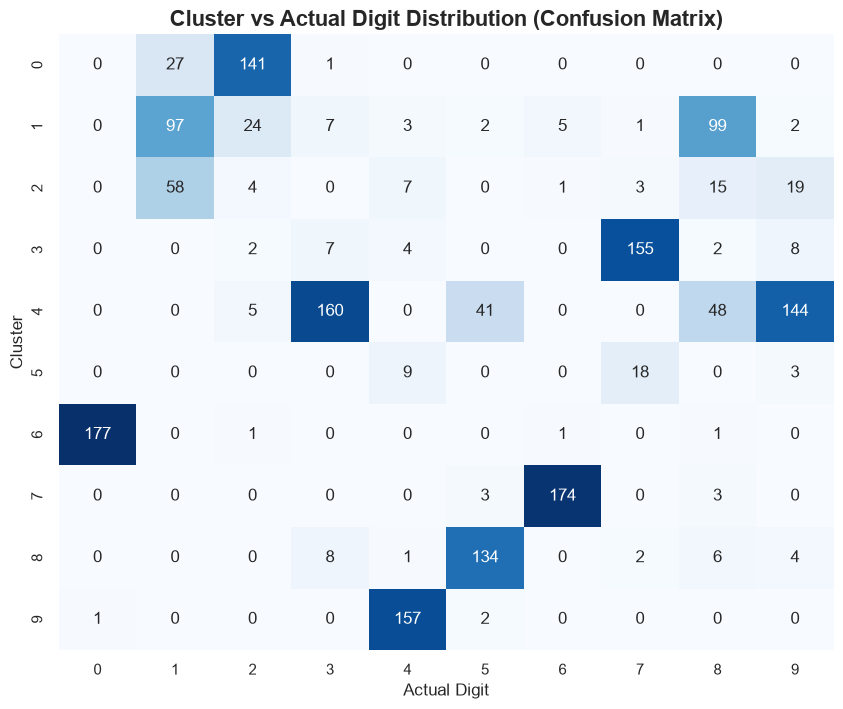

,Metric,Value
0,Adjusted Rand Index (ARI),0.566691
1,Normalized Mutual Information (NMI),0.696638
2,Silhouette Score,0.150088
3,Calinski-Harabasz Index,113.823889
4,Davies-Bouldin Index,1.869172


In [10]:
comparison_df = pd.crosstab(cluster_labels, y_true, rownames=["Cluster"], colnames=["Actual Digit"])

plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Cluster vs Actual Digit Distribution (Confusion Matrix)", fontsize=16, fontweight='bold')
plt.show()

ari       = adjusted_rand_score(y_true, cluster_labels)
nmi       = normalized_mutual_info_score(y_true, cluster_labels)
final_sil = silhouette_score(x_scaled, cluster_labels)
final_ch  = calinski_harabasz_score(x_scaled, cluster_labels)
final_db  = davies_bouldin_score(x_scaled, cluster_labels)

summary   = pd.DataFrame({
    "Metric"  : [
        "Adjusted Rand Index (ARI)",
        "Normalized Mutual Information (NMI)",
        "Silhouette Score",
        "Calinski-Harabasz Index",
        "Davies-Bouldin Index"
    ],
    "Value"   : [
        ari,
        nmi,
        final_sil,
        final_ch,
        final_db
    ]
})
summary 

### Step 11: Conclusion & Summary
1. **Elbow, Silhouette, Calinski-Harabasz, and Davies-Bouldin plots** together give a far more complete internal validation picture than any single metric alone — on this 64-dimensional dataset, they do not all peak at exactly the same K, illustrating why relying on one metric can be misleading.
2. **K-Means++ initialization** produced consistently lower and more stable inertia across random seeds compared to purely random initialization, confirming its role in avoiding poor local minima.
3. **PCA dimensionality reduction before clustering** (retaining 90% variance, 64 to 31 dimensions) preserved most of the clustering quality while reducing computational dimensionality, though it did not universally outperform clustering on the full standardized feature space.
4. **Per-sample silhouette diagnostics** revealed that certain digit clusters (e.g., visually similar digits such as 4/9 or 3/8) have thinner, more ambiguous silhouette profiles than clearly distinct digits like 0 or 6.
5. **Cluster centroids reconstructed as digit images** provided an intuitive, human-verifiable check on cluster quality, distinct from any purely numerical metric.
6. **Voronoi tessellation** made the centroid-based decision regions directly visible, showing exactly how K-Means partitions the PCA-projected feature space between the 10 digit clusters.
7. Validated against true digit labels using **ARI and NMI**, the K=10 clustering achieved strong (though imperfect) alignment with ground truth, consistent with the intrinsic pixel-level overlap between certain handwritten digits.

**Experiment Completed Successfully.**